# SentinelFlow AI — CIC-IDS2017 Dataset Overview

This notebook performs the initial exploration of the CIC-IDS2017 network intrusion detection dataset.

## Objectives

- Discover and validate the available dataset files
- Inspect the dataset structure and features
- Measure the total number of network flows
- Identify benign and malicious traffic classes
- Analyze attack class distribution
- Check for missing, infinite, and duplicate values
- Identify potential data quality issues before preprocessing and modeling

> This notebook is part of the data exploration phase of SentinelFlow AI.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

print("Environment ready.")

Environment ready.


In [3]:
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

test_df = pd.DataFrame({
    "traffic": ["benign", "attack"],
    "value": [1, 2]
})

test_df

Pandas: 3.0.5
NumPy: 2.5.2


,traffic,value
0,benign,1
1,attack,2


In [4]:
DATA_DIR = Path("../data/raw")

csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"Dataset directory: {DATA_DIR.resolve()}")
print(f"CSV files found: {len(csv_files)}")

for file in csv_files:
    print(f"- {file.name}")

Dataset directory: C:\Users\abdal\SentinelFlow-AI\data\raw
CSV files found: 8
- Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
- Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
- Friday-WorkingHours-Morning.pcap_ISCX.csv
- Monday-WorkingHours.pcap_ISCX.csv
- Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
- Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
- Tuesday-WorkingHours.pcap_ISCX.csv
- Wednesday-workingHours.pcap_ISCX.csv


In [ ]:
sample_file = csv_files[0]

sample_df = pd.read_csv(sample_file, nrows=5)

print(f"Sample file: {sample_file.name}")
print(f"Columns: {sample_df.shape[1]}")
print(f"Sample rows: {sample_df.shape[0]}")

sample_df

In [2]:
DATA_DIR = Path("../data/raw")

csv_files = sorted(DATA_DIR.glob("*.csv"))

sample_file = csv_files[0]
sample_df = pd.read_csv(sample_file, nrows=5)

print(f"Sample file: {sample_file.name}")
print(f"Shape: {sample_df.shape}")
print(f"Number of features: {sample_df.shape[1]}")

Sample file: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Shape: (5, 79)
Number of features: 79


In [3]:
print(f"Total columns: {len(sample_df.columns)}\n")

for i, column in enumerate(sample_df.columns, start=1):
    print(f"{i:02d}. {repr(column)}")

Total columns: 79

01. ' Destination Port'
02. ' Flow Duration'
03. ' Total Fwd Packets'
04. ' Total Backward Packets'
05. 'Total Length of Fwd Packets'
06. ' Total Length of Bwd Packets'
07. ' Fwd Packet Length Max'
08. ' Fwd Packet Length Min'
09. ' Fwd Packet Length Mean'
10. ' Fwd Packet Length Std'
11. 'Bwd Packet Length Max'
12. ' Bwd Packet Length Min'
13. ' Bwd Packet Length Mean'
14. ' Bwd Packet Length Std'
15. 'Flow Bytes/s'
16. ' Flow Packets/s'
17. ' Flow IAT Mean'
18. ' Flow IAT Std'
19. ' Flow IAT Max'
20. ' Flow IAT Min'
21. 'Fwd IAT Total'
22. ' Fwd IAT Mean'
23. ' Fwd IAT Std'
24. ' Fwd IAT Max'
25. ' Fwd IAT Min'
26. 'Bwd IAT Total'
27. ' Bwd IAT Mean'
28. ' Bwd IAT Std'
29. ' Bwd IAT Max'
30. ' Bwd IAT Min'
31. 'Fwd PSH Flags'
32. ' Bwd PSH Flags'
33. ' Fwd URG Flags'
34. ' Bwd URG Flags'
35. ' Fwd Header Length'
36. ' Bwd Header Length'
37. 'Fwd Packets/s'
38. ' Bwd Packets/s'
39. ' Min Packet Length'
40. ' Max Packet Length'
41. ' Packet Length Mean'
42. ' Packet 

## Schema Inspection and Column Name Cleaning

Initial inspection revealed inconsistent leading and trailing whitespace across the CIC-IDS2017 column names.

To prevent ambiguous column references and downstream processing errors, column names are normalized by removing surrounding whitespace.

Potential duplicate or redundant features are not removed at this stage; they will be investigated separately.

In [4]:
original_columns = sample_df.columns.tolist()

sample_df.columns = sample_df.columns.str.strip()

changed_columns = [
    (old, new)
    for old, new in zip(original_columns, sample_df.columns)
    if old != new
]

print(f"Columns cleaned: {len(changed_columns)}")
print(f"Total columns: {len(sample_df.columns)}")
print(f"Target column found: {'Label' in sample_df.columns}")

Columns cleaned: 65
Total columns: 79
Target column found: True


## Dataset Schema Validation

Before combining the CIC-IDS2017 files, the schema of all CSV files is validated.

For each file, we inspect the column structure and normalize column names by removing surrounding whitespace. This ensures that all files follow a consistent schema before further analysis or preprocessing.

In [5]:
reference_columns = sample_df.columns.tolist()
schema_results = []

for file in csv_files:
    columns = pd.read_csv(file, nrows=0).columns.str.strip().tolist()

    schema_results.append({
        "file": file.name,
        "columns": len(columns),
        "matches_reference": columns == reference_columns
    })

schema_df = pd.DataFrame(schema_results)

schema_df

,file,columns,matches_reference
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,79,True
1,Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,79,True
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,79,True
3,Monday-WorkingHours.pcap_ISCX.csv,79,True
4,Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,79,True
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,79,True
6,Tuesday-WorkingHours.pcap_ISCX.csv,79,True
7,Wednesday-workingHours.pcap_ISCX.csv,79,True


## Dataset Size Analysis

The CIC-IDS2017 dataset is distributed across eight CSV files representing different traffic scenarios.

Before loading the complete dataset into memory, we measure the number of network flows contained in each file and estimate the overall dataset size.

In [6]:
file_stats = []

for file in csv_files:
    with open(file, "r", encoding="utf-8", errors="ignore") as f:
        row_count = sum(1 for _ in f) - 1

    file_stats.append({
        "file": file.name,
        "network_flows": row_count,
        "size_mb": file.stat().st_size / (1024 ** 2)
    })

file_stats_df = pd.DataFrame(file_stats)

file_stats_df

,file,network_flows,size_mb
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,73.551044
1,Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,286467,73.343437
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,55.615163
3,Monday-WorkingHours.pcap_ISCX.csv,529918,168.731611
4,Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,288602,79.252659
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,170366,49.613250
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,128.821368
7,Wednesday-workingHours.pcap_ISCX.csv,692703,214.735408


In [7]:
total_flows = file_stats_df["network_flows"].sum()
total_size_mb = file_stats_df["size_mb"].sum()

print(f"Total network flows: {total_flows:,}")
print(f"Total dataset size: {total_size_mb:.2f} MB")

Total network flows: 2,830,743
Total dataset size: 843.66 MB


## Traffic Class and Attack Distribution

The next step is to examine the labels across the complete CIC-IDS2017 dataset.

This analysis identifies the available attack categories, measures the distribution of benign and malicious traffic, and highlights potential class imbalance that may affect model training and evaluation.

In [8]:
label_frames = []

for file in csv_files:
    labels = pd.read_csv(file, usecols=lambda col: col.strip() == "Label")
    labels.columns = labels.columns.str.strip()
    label_frames.append(labels)

labels_df = pd.concat(label_frames, ignore_index=True)

print(f"Labels loaded: {len(labels_df):,}")
print(f"Unique traffic classes: {labels_df['Label'].nunique()}")

Labels loaded: 2,830,743
Unique traffic classes: 15


In [9]:
class_distribution = (
    labels_df["Label"]
    .value_counts()
    .rename_axis("traffic_class")
    .reset_index(name="flows")
)

class_distribution["percentage"] = (
    class_distribution["flows"] / len(labels_df) * 100
)

class_distribution

,traffic_class,flows,percentage
0,BENIGN,2273097,80.300366
1,DoS Hulk,231073,8.162981
2,PortScan,158930,5.614427
3,DDoS,128027,4.522735
4,DoS GoldenEye,10293,0.363615
5,FTP-Patator,7938,0.280421
6,SSH-Patator,5897,0.208320
7,DoS slowloris,5796,0.204752
8,DoS Slowhttptest,5499,0.194260
9,Bot,1966,0.069452


## Benign vs. Malicious Traffic

In addition to multiclass attack classification, SentinelFlow AI will treat intrusion detection as a binary security problem:

- **Benign:** legitimate network traffic
- **Malicious:** any traffic associated with an attack

This view provides a high-level understanding of the class imbalance between normal and malicious network activity.

In [10]:
binary_distribution = (
    labels_df["Label"]
    .eq("BENIGN")
    .map({True: "Benign", False: "Malicious"})
    .value_counts()
    .rename_axis("traffic_type")
    .reset_index(name="flows")
)

binary_distribution["percentage"] = (
    binary_distribution["flows"] / len(labels_df) * 100
)

binary_distribution

,traffic_type,flows,percentage
0,Benign,2273097,80.300366
1,Malicious,557646,19.699634


## Benign vs. Malicious Traffic Distribution

The dataset is dominated by benign network traffic, while malicious flows account for approximately one-fifth of all observations.

Understanding this imbalance is important because accuracy alone may provide a misleading assessment of intrusion detection performance. Later modeling stages will therefore consider additional evaluation metrics such as precision, recall, F1-score, and confusion matrices.

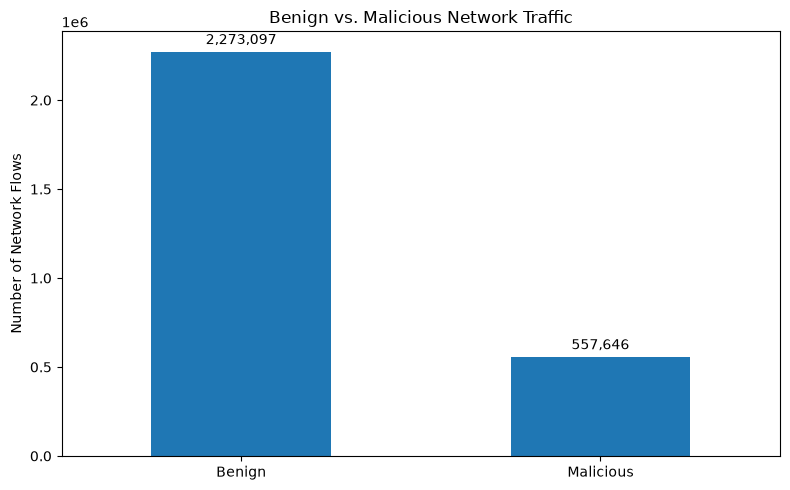

In [11]:
plot_data = binary_distribution.set_index("traffic_type")["flows"]

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Benign vs. Malicious Network Traffic")
ax.set_xlabel("")
ax.set_ylabel("Number of Network Flows")
ax.tick_params(axis="x", rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)

plt.tight_layout()
plt.show()

## Cyberattack Class Distribution

To understand the multiclass classification problem, benign traffic is excluded and the distribution of individual attack categories is analyzed separately.

This reveals whether certain attack types dominate the malicious traffic and whether rare attack classes may require special consideration during model training and evaluation.

In [12]:
attack_distribution = (
    class_distribution[class_distribution["traffic_class"] != "BENIGN"]
    .copy()
)

attack_distribution["attack_percentage"] = (
    attack_distribution["flows"]
    / attack_distribution["flows"].sum()
    * 100
)

attack_distribution

,traffic_class,flows,percentage,attack_percentage
1,DoS Hulk,231073,8.162981,41.437220
2,PortScan,158930,5.614427,28.500160
3,DDoS,128027,4.522735,22.958472
4,DoS GoldenEye,10293,0.363615,1.845795
5,FTP-Patator,7938,0.280421,1.423484
6,SSH-Patator,5897,0.208320,1.057481
7,DoS slowloris,5796,0.204752,1.039369
8,DoS Slowhttptest,5499,0.194260,0.986109
9,Bot,1966,0.069452,0.352553
10,Web Attack � Brute Force,1507,0.053237,0.270243


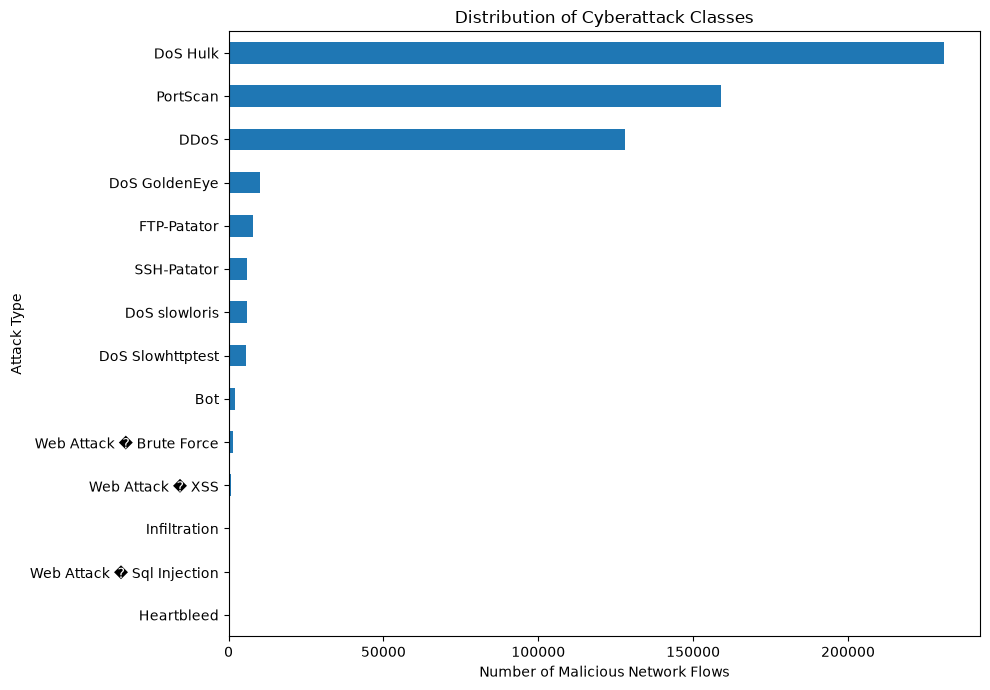

In [13]:
attack_plot = attack_distribution.sort_values("flows")

ax = attack_plot.plot(
    x="traffic_class",
    y="flows",
    kind="barh",
    figsize=(10, 7),
    legend=False
)

ax.set_title("Distribution of Cyberattack Classes")
ax.set_xlabel("Number of Malicious Network Flows")
ax.set_ylabel("Attack Type")

plt.tight_layout()
plt.show()

## Data Quality Assessment

Before preprocessing and model training, the dataset is examined for common data quality issues.

The analysis focuses on:
- Missing values
- Positive and negative infinity values
- Duplicate network flows
- Non-numeric feature values

These issues must be identified before building the machine learning pipeline.

In [15]:
quality_results = []

for file in csv_files:
    df = pd.read_csv(file, low_memory=False)
    df.columns = df.columns.str.strip()

    numeric_df = df.select_dtypes(include=[np.number])

    missing_values = int(df.isna().sum().sum())
    positive_inf = int(np.isposinf(numeric_df).sum().sum())
    negative_inf = int(np.isneginf(numeric_df).sum().sum())

    quality_results.append({
        "file": file.name,
        "rows": len(df),
        "missing_values": missing_values,
        "positive_inf": positive_inf,
        "negative_inf": negative_inf
    })

    del df, numeric_df

quality_df = pd.DataFrame(quality_results)

quality_df

,file,rows,missing_values,positive_inf,negative_inf
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,4,64,0
1,Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,286467,15,727,0
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,28,216,0
3,Monday-WorkingHours.pcap_ISCX.csv,529918,64,810,0
4,Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,288602,18,396,0
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,170366,20,250,0
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,201,327,0
7,Wednesday-workingHours.pcap_ISCX.csv,692703,1008,1586,0


In [16]:
total_missing = quality_df["missing_values"].sum()
total_positive_inf = quality_df["positive_inf"].sum()
total_negative_inf = quality_df["negative_inf"].sum()

print(f"Total missing values: {total_missing:,}")
print(f"Total positive infinity values: {total_positive_inf:,}")
print(f"Total negative infinity values: {total_negative_inf:,}")

Total missing values: 1,358
Total positive infinity values: 4,376
Total negative infinity values: 0


## Problematic Features

After identifying missing and infinite values across the dataset, the next step is to determine which features contain these data quality issues.

This helps define targeted preprocessing rules instead of applying unnecessary transformations to the entire feature set.

In [17]:
column_quality = {}

for file in csv_files:
    df = pd.read_csv(file, low_memory=False)
    df.columns = df.columns.str.strip()

    for column in df.columns:
        if column == "Label":
            continue

        if column not in column_quality:
            column_quality[column] = {
                "missing": 0,
                "positive_inf": 0,
                "negative_inf": 0
            }

        column_quality[column]["missing"] += int(df[column].isna().sum())

        if pd.api.types.is_numeric_dtype(df[column]):
            column_quality[column]["positive_inf"] += int(
                np.isposinf(df[column]).sum()
            )

            column_quality[column]["negative_inf"] += int(
                np.isneginf(df[column]).sum()
            )

    del df

column_quality_df = (
    pd.DataFrame.from_dict(column_quality, orient="index")
    .reset_index()
    .rename(columns={"index": "feature"})
)

problematic_features = column_quality_df[
    (column_quality_df["missing"] > 0)
    | (column_quality_df["positive_inf"] > 0)
    | (column_quality_df["negative_inf"] > 0)
].sort_values(
    by=["missing", "positive_inf"],
    ascending=False
)

problematic_features

,feature,missing,positive_inf,negative_inf
14,Flow Bytes/s,1358,1509,0
15,Flow Packets/s,0,2867,0


## Duplicate Flow Assessment

Duplicate network flows can bias the training process by overrepresenting repeated observations.

To avoid excessive memory usage, duplicate rows are first examined independently within each dataset file.

In [18]:
duplicate_results = []

for file in csv_files:
    df = pd.read_csv(file, low_memory=False)
    df.columns = df.columns.str.strip()

    duplicate_count = int(df.duplicated().sum())

    duplicate_results.append({
        "file": file.name,
        "rows": len(df),
        "duplicate_rows": duplicate_count,
        "duplicate_percentage": (duplicate_count / len(df)) * 100
    })

    del df

duplicate_df = pd.DataFrame(duplicate_results)

duplicate_df

,file,rows,duplicate_rows,duplicate_percentage
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,2633,1.166360
1,Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,286467,72353,25.257010
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,6888,3.605660
3,Monday-WorkingHours.pcap_ISCX.csv,529918,26935,5.082862
4,Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,288602,35630,12.345722
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,170366,6066,3.560570
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,24065,5.396841
7,Wednesday-workingHours.pcap_ISCX.csv,692703,81909,11.824548


In [19]:
total_duplicates = duplicate_df["duplicate_rows"].sum()
total_rows = duplicate_df["rows"].sum()
duplicate_percentage = (total_duplicates / total_rows) * 100

print(f"Total rows: {total_rows:,}")
print(f"Duplicate rows within files: {total_duplicates:,}")
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Total rows: 2,830,743
Duplicate rows within files: 256,479
Duplicate percentage: 9.06%


## Dataset Exploration Summary

The initial exploration of the CIC-IDS2017 dataset produced the following findings:

- The dataset consists of 8 CSV files.
- A total of 2,830,743 network flows were identified.
- Each file contains 79 columns with a consistent schema.
- The dataset contains 15 traffic classes.
- Benign traffic represents approximately 80.30% of all network flows.
- Malicious traffic represents approximately 19.70% of all network flows.
- The malicious traffic distribution is highly imbalanced, with DoS Hulk, PortScan, and DDoS representing the majority of attack flows.
- A total of 1,358 missing values were identified.
- A total of 4,376 positive infinity values were identified.
- No negative infinity values were found.
- Data quality issues involving missing and infinite values are limited to `Flow Bytes/s` and `Flow Packets/s`.
- 256,479 duplicate rows were detected within individual CSV files, representing approximately 9.06% of the complete dataset.

### Key Preprocessing Considerations

The preprocessing pipeline should therefore address:

1. Missing values.
2. Infinite values in flow-rate features.
3. Duplicate network flows.
4. Inconsistent whitespace in column names.
5. Class imbalance between benign and malicious traffic.
6. Severe imbalance between individual attack classes.

No modifications were made to the raw dataset during this exploration phase.